# H2 分子 VQE 完整教程（4-Qubit）

本教程面向首次使用者，目标是在同一份 notebook 中完成：
- 从量子化学模型得到 H2 的 4-qubit 哈密顿量
- 构建一个 H2 专用的 UCC-style 参数化电路
- 使用 VQE 进行参数优化并与 FCI 基准比较
- 对照三种 ansatz：`hardwareefficient`、`ucc`、`custom`

---

## 理论背景（从分子到量子线路）

电子哈密顿量（二次量子化）为：

$$
\hat H = \sum_{pq} h_{pq} a_p^\dagger a_q + \frac{1}{2}\sum_{pqrs} h_{pqrs} a_p^\dagger a_q^\dagger a_r a_s
$$

将其映射到 qubit 空间后，得到 Pauli 算符线性组合：

$$
\hat H_q = c_0 I + \sum_{k} c_k P_k,\quad P_k \in \{I,X,Y,Z\}^{\otimes n}
$$

VQE 的优化目标是最小化：

$$
E(\theta) = \langle \psi(\theta) | \hat H_q | \psi(\theta) \rangle
$$

将上式代入 Pauli 分解可得：

$$
E(\theta)=c_0+\sum_k c_k\langle \psi(\theta)|P_k|\psi(\theta)\rangle
$$

这说明 VQE 的数值任务可分解为两步：
1. 准备参数化态 $|\psi(\theta)\rangle$。
2. 估计每个 Pauli 项期望值并按系数加权求和。

当 ansatz 足够表达基态且优化收敛时，估计能量应接近 FCI 参考值。

默认读取文件：
- `../data/h2_R2.6_angstrom_sto-3g.json`

若文件不存在，请在 WSL 中执行：
```bash
cd /mnt/d/OneDrive/work/research/code/Quantum_control
python chemistry/scripts/export_h2_terms_wsl.py --R 2.6 --unit angstrom --output chemistry/data/h2_R2.6_angstrom_sto-3g.json
```

读取后可获得：
- `h2_constant`
- `h2_4q_terms`
- `nqubits`
- `fci_energy`

In [6]:
from pathlib import Path
import json
import math

# Geometry / chemistry config
R = 2.6
R_UNIT = 'angstrom'
BASIS = 'sto-3g'
MULTIPLICITY = 1
CHARGE = 0

# VQE config
cfg = {
    'layers': 1,
    'shots': 4096,
    'max_iters': 30,
    'learning_rate': 0.2,
    'seed': 7,
    'gradient_method': 'autograd',
    'prefer_chips': 'Simulator',
    'shift': math.pi / 2,
}

print('R =', R, R_UNIT)
print('Basis =', BASIS)
print('VQE cfg =', cfg)

R = 2.6 angstrom
Basis = sto-3g
VQE cfg = {'layers': 1, 'shots': 4096, 'max_iters': 30, 'learning_rate': 0.2, 'seed': 7, 'gradient_method': 'autograd', 'prefer_chips': 'Simulator', 'shift': 1.5707963267948966}


默认读取文件：
- `../data/h2_R2.6_angstrom_sto-3g.json`

若文件不存在，请在 WSL 中执行：
```bash
cd /mnt/d/OneDrive/work/research/code/Quantum_control
python chemistry/scripts/export_h2_terms_wsl.py --R 2.6 --unit angstrom --output chemistry/data/h2_R2.6_angstrom_sto-3g.json
```

读取后可获得：
- `h2_constant`
- `h2_4q_terms`
- `nqubits`
- `fci_energy`

In [7]:
from __future__ import annotations

import os
import json
from pathlib import Path

# Work around duplicated OpenMP runtime loading on Windows notebook kernels.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

from quantum_hw import QuantumHardwareClient
from quantum_hw.algorithms import VQERunner

json_path = Path('../data/h2_R2.6_angstrom_sto-3g.json')
if not json_path.exists():
    raise FileNotFoundError(
        f'Missing {json_path}. Generate it in WSL with:\n'
        'python chemistry/scripts/export_h2_terms_wsl.py --R 2.6 --unit angstrom '
        '--output chemistry/data/h2_R2.6_angstrom_sto-3g.json'
    )

data = json.loads(json_path.read_text(encoding='utf-8'))

h2_constant = float(data['constant'])
h2_4q_terms = [(float(c), str(obs)) for c, obs in data['terms']]
nqubits = int(data['nqubits'])
fci_energy = float(data['fci_energy'])

print('Loaded from:', json_path)
print('nqubits:', nqubits)
print('term_count:', len(h2_4q_terms))
print('fci_energy:', fci_energy)


Loaded from: ..\data\h2_R2.6_angstrom_sto-3g.json
nqubits: 4
term_count: 14
fci_energy: -0.9351960308474745


## 3. 在 4-qubit 哈密顿量上运行 VQE，并与 FCI 对照

该单元将：
- 使用上一步自动生成的 `h2_4q_terms`
- 在 `num_qubits = 4` 上运行你的框架 VQE（使用默认hardware-efficient ansatz）
- 计算总能量 `E_total = h2_constant + E_nonconst`
- 与 `fci_energy` 做误差对比（可验证）

[vqe] prepare run: name=h2_4q_demo_notebook num_qubits=4 provider=quafu model=custom layers=1 shots=4096 max_iters=30
[vqe] candidate chips: ['Simulator']
[vqe] running on chip: Simulator
[vqe] start optimization: iters=30 layers=1 params=16 ansatz=hardwareefficient shots=4096 shift=1.5707963267948966 gradient=autograd
[vqe] iter 0 start
[vqe] iter 0 energy=0.097025 grad_norm=0.275339
[vqe] iter 0 new best energy=0.097025
[vqe] iter 1 start
[vqe] iter 1 energy=-0.056742 grad_norm=0.202049
[vqe] iter 1 new best energy=-0.056742
[vqe] iter 2 start
[vqe] iter 2 energy=-0.130675 grad_norm=0.112868
[vqe] iter 2 new best energy=-0.130675
[vqe] iter 3 start
[vqe] iter 3 energy=-0.139752 grad_norm=0.130615
[vqe] iter 3 new best energy=-0.139752
[vqe] iter 4 start
[vqe] iter 4 energy=-0.138344 grad_norm=0.151034
[vqe] iter 5 start
[vqe] iter 5 energy=-0.151344 grad_norm=0.141608
[vqe] iter 5 new best energy=-0.151344
[vqe] iter 6 start
[vqe] iter 6 energy=-0.172119 grad_norm=0.133684
[vqe] iter

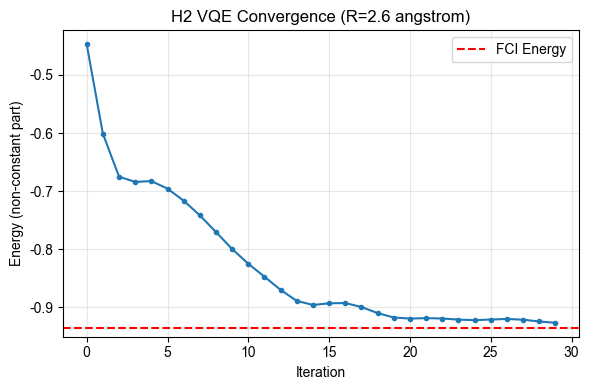

In [8]:
client = QuantumHardwareClient()
runner = VQERunner(
    client=client,
    layers=cfg['layers'],
    shots=cfg['shots'],
    max_iters=cfg['max_iters'],
    learning_rate=cfg['learning_rate'],
    gradient_method=cfg['gradient_method'],
    seed=cfg['seed'],
)

result = runner.run_model(
    name='h2_4q_demo_notebook',
    num_qubits=nqubits,
    model='custom',
    hamiltonian=h2_4q_terms,
    prefer_chips=cfg['prefer_chips'],
)

best_total_energy = h2_constant + result.best_energy
abs_error_fci = abs(best_total_energy - fci_energy)

print('=== 4-Qubit H2 VQE Result ===')
print('Estimated total energy:  ', round(best_total_energy, 8))
print('FCI reference energy:    ', round(fci_energy, 8))
print('Absolute error vs FCI:   ', round(abs_error_fci, 8))

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6, 4))
plt.plot(np.array(result.energy_history) + h2_constant, marker='o', ms=3)
plt.axhline(fci_energy, color='red', linestyle='--', label='FCI Energy')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Energy (non-constant part)')
plt.title(f'H2 VQE Convergence (R={R} {R_UNIT})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. 构建 H2 专用 UCC-style Custom Ansatz

这一步我们手工定义一个“面向 H2 的”参数化电路模板，并交给 `custom` 接口优化。

### 设计思想
- 参考态：先准备 Hartree-Fock (HF) 占据态（示例 `|1100>`，与映射约定相关）。
- 单激发（singles-like）：在占据轨道与虚轨道之间加入参数化混合。
- 双激发（doubles-like）：加入相关激发近似块，增强电子关联表达能力。

### The **Unitary Coupled Cluster (UCC)** ansatz is

$$
U(\theta) = e^{T - T^\dagger}
$$
where

$$
T = T_1 + T_2
$$

- $T_1$: single excitations  
- $T_2$: double excitations  

For the H₂ system, the most important contribution is the **double excitation**

$$
a_3^\dagger a_2^\dagger a_1 a_0
$$

Thus the ansatz becomes

$$
U(\theta) =
\exp\Big[
\theta(
a_3^\dagger a_2^\dagger a_1 a_0
-
a_0^\dagger a_1^\dagger a_2 a_3
)
\Big]
$$

### Pauli Representation

After the **Jordan–Wigner transformation**, the double excitation operator maps to a sum of Pauli strings:

$$
U(\theta) =
\exp\left[
-i\theta
Y_0 Y_1 Y_2 X_3
\right]
$$

Therefore the unitary can be implemented as four Pauli rotations.

### Circuit Structure

Each Pauli exponential $e^{-i\phi P}$ is implemented with the standard pattern:

1. **Basis change** (convert X/Y to Z basis)
2. **CNOT ladder** to collect parity
3. **RZ rotation**
4. **Undo CNOT ladder**
5. **Undo basis change**

In [9]:
from quantum_hw import QuantumHardwareClient
from quantum_hw.algorithms import VQERunner
from quantum_hw.circuit import QuantumCircuit

def build_h2_ucc_style_symbolic_ansatz() -> QuantumCircuit:
    qc = QuantumCircuit(4)

    # -------------------------
    # Hartree–Fock reference
    # |1100>
    # -------------------------

    qc.x(0)
    qc.x(1)

    qc.pauli_evolution("theta", "Y0 Y1 Y2 X3")
    return qc

custom_ansatz_qc = build_h2_ucc_style_symbolic_ansatz()
custom_ansatz_qc.draw()
symbolic_params = sorted(
    [k for k, v in custom_ansatz_qc.params_value.items() if isinstance(k, str) and isinstance(v, str)]
)
print('Total gates in custom H2-UCC-style ansatz:', len(custom_ansatz_qc.gates))

Total gates in custom H2-UCC-style ansatz: 23


## 4. 运行 VQE 并对照两种 Ansatz

在同一哈密顿量上分别运行：
- `hardwareefficient`：硬件友好、通用性强。
- `custom`：本教程构建的 H2 专用 UCC-style 模板。

### 结果解读方法
- `best_total = h2_constant + best_nonconst`：估计总能量。
- `abs_err_fci = |best_total - fci_energy|`：相对 FCI 的误差。
- 收敛曲线：观察优化稳定性与下降速度。

通常来说，加入更强问题结构先验的 ansatz，往往在相同预算下能得到更低误差，但并不绝对。

[vqe] prepare run: name=lih_6q_custom num_qubits=4 provider=quafu model=custom layers=1 shots=4096 max_iters=15
[vqe] candidate chips: ['Simulator']
[vqe] running on chip: Simulator
[vqe] start optimization: iters=15 layers=1 params=1 ansatz=custom shots=4096 shift=1.5707963267948966 gradient=autograd
[vqe] iter 0 start
[vqe] iter 0 energy=-0.149912 grad_norm=0.285577
[vqe] iter 0 new best energy=-0.149912
[vqe] iter 1 start
[vqe] iter 1 energy=-0.192041 grad_norm=0.275095
[vqe] iter 1 new best energy=-0.192041
[vqe] iter 2 start
[vqe] iter 2 energy=-0.232093 grad_norm=0.258453
[vqe] iter 2 new best energy=-0.232093
[vqe] iter 3 start
[vqe] iter 3 energy=-0.269117 grad_norm=0.236087
[vqe] iter 3 new best energy=-0.269117
[vqe] iter 4 start
[vqe] iter 4 energy=-0.302224 grad_norm=0.208624
[vqe] iter 4 new best energy=-0.302224
[vqe] iter 5 start
[vqe] iter 5 energy=-0.330638 grad_norm=0.176902
[vqe] iter 5 new best energy=-0.330638
[vqe] iter 6 start
[vqe] iter 6 energy=-0.353753 grad_n

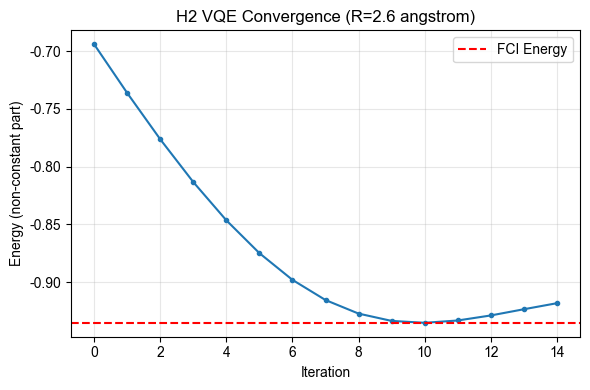

In [10]:
cfg['max_iters'] = 15
cfg['learning_rate'] = 0.15
runner = VQERunner(
    client=QuantumHardwareClient(),
    layers=cfg['layers'],
    shots=cfg['shots'],
    max_iters=cfg['max_iters'],
    learning_rate=cfg['learning_rate'],
    gradient_method=cfg['gradient_method'],
    seed=cfg['seed'],
    shift=cfg['shift'],
)

kwargs = {
    'name': f'lih_6q_custom',
    'num_qubits': nqubits,
    'model': 'custom',
    'hamiltonian': h2_4q_terms,
    'ansatz': 'custom',
    'custom_ansatz_circuit': custom_ansatz_qc,
    'prefer_chips': cfg['prefer_chips'],
    'init_params': [0.01]*len(symbolic_params),
}

res = runner.run_model(**kwargs)
e_total = h2_constant + res.best_energy
abs_error_fci = abs(e_total - fci_energy)

print('=== 4-Qubit LiH VQE Result ===')
print('Estimated total energy:  ', round(e_total, 8))
print('FCI reference energy:    ', round(fci_energy, 8))
print('Absolute error vs FCI:   ', round(abs_error_fci, 8))

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6, 4))
plt.plot(np.array(res.energy_history) + h2_constant, marker='o', ms=3)
plt.axhline(fci_energy, color='red', linestyle='--', label='FCI Energy')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Energy (non-constant part)')
plt.title(f'H2 VQE Convergence (R={R} {R_UNIT})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 在真实硬件上运行线路
结合ZNE、REM和CF

[vqe] prepare run: name=h2_4q_cmp_custom num_qubits=4 provider=quafu model=custom layers=1 shots=4096 max_iters=15
[vqe] candidate chips: ['Baihua']
[vqe] running on chip: Baihua
[vqe] clifford fitting prepared: terms=14 samples=8 non_clifford_gates=3
[vqe] start optimization: iters=15 layers=1 params=1 ansatz=custom shots=4096 shift=1.5707963267948966 gradient=parameter-shift
[vqe] iter 0 start
[vqe] iter 0 energy=-0.168744 grad_norm=0.261205
[vqe] iter 0 new best energy=-0.168744
[vqe] iter 1 start
[vqe] iter 1 energy=-0.181296 grad_norm=0.256484
[vqe] iter 1 new best energy=-0.181296
[vqe] iter 2 start
[vqe] iter 2 energy=-0.212749 grad_norm=0.232571
[vqe] iter 2 new best energy=-0.212749
[vqe] iter 3 start
[vqe] iter 3 energy=-0.257341 grad_norm=0.192304
[vqe] iter 3 new best energy=-0.257341
[vqe] iter 4 start
[vqe] iter 4 energy=-0.286562 grad_norm=0.186494
[vqe] iter 4 new best energy=-0.286562
[vqe] iter 5 start
[vqe] iter 5 energy=-0.289170 grad_norm=0.150581
[vqe] iter 5 new 

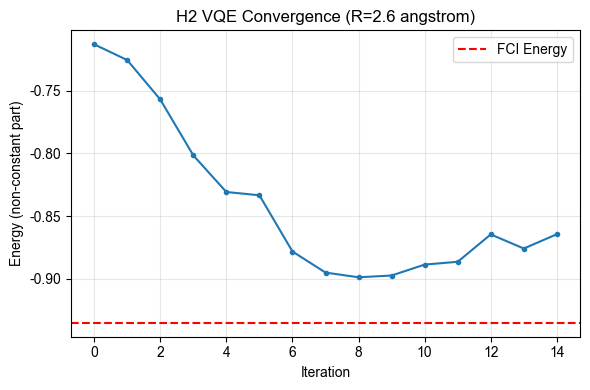

In [12]:
cfg['prefer_chips'] = 'Baihua'
cfg['zne'] = True
cfg['readout_mitigation'] = True
cfg['clifford_fitting'] = True
cfg['clifford_fitting_num_samples'] = 8
cfg['gradient_method'] = 'parameter-shift'

runner_cmp = VQERunner(
    client=QuantumHardwareClient(),
    layers=cfg['layers'],
    shots=cfg['shots'],
    max_iters=cfg['max_iters'],
    learning_rate=cfg['learning_rate'],
    gradient_method=cfg['gradient_method'],
    seed=cfg['seed'],
    zne=cfg['zne'],
    readout_mitigation=cfg['readout_mitigation'],
    shift=cfg['shift'],
    clifford_fitting=cfg['clifford_fitting'],
    clifford_fitting_num_samples=cfg['clifford_fitting_num_samples'],
)

kwargs = {
    'name': f'h2_4q_cmp_custom',
    'num_qubits': nqubits,
    'model': 'custom',
    'hamiltonian': h2_4q_terms,
    'ansatz': 'custom',
    'custom_ansatz_circuit': custom_ansatz_qc,
    'prefer_chips': cfg['prefer_chips'],
    'init_params': [0.01]*len(symbolic_params),
}

res = runner_cmp.run_model(**kwargs)
e_total = h2_constant + res.best_energy
abs_error_fci = abs(e_total - fci_energy)

print('=== 4-Qubit H2 VQE Result ===')
print('Estimated total energy:  ', round(e_total, 8))
print('FCI reference energy:    ', round(fci_energy, 8))
print('Absolute error vs FCI:   ', round(abs_error_fci, 8))

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6, 4))
plt.plot(np.array(res.energy_history) + h2_constant, marker='o', ms=3)
plt.axhline(fci_energy, color='red', linestyle='--', label='FCI Energy')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Energy (non-constant part)')
plt.title(f'H2 VQE Convergence (R={R} {R_UNIT})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()